# The Need for Nestedness (Linear Models Experiments)

This notebook reproduces the synthetic linear-model study from Section 4 of `FlexRank: Nested Low-Rank Knowledge Decomposition for Adaptive Model Deployment` and the three panels of Figure 2: Post-Training Selection (PTS), All-Subspaces Learning (ASL), and Nested Subspace Learning (NSL).

## Imports and setup

The implementation now stays on top of the public trainer API: `StandardTrainer`, `FlexRankTrainer`, and the samplers exported by `flexrank.samplers`. The only notebook-local customization is the regression loss wrapper needed because the synthetic experiment optimizes squared error rather than classification loss.


In [1]:
import math
import os
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset
from tqdm.auto import trange

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from flexrank.samplers import AllLayerLinearSampler, PredefinedModelsSampler
from flexrank.trainers import (
    EvalLoopOutput,
    FlexRankTrainArguments,
    FlexRankTrainer,
    StandardTrainer,
    SVDTrainer,
    SVDTrainingArguments,
    SVDType,
    TrainingArguments,
    TrainOutput,
)
from flexrank.types import get_single_worker_distributed_info

plt.rcParams.update({"font.size": 14})
legend_position = "upper right"

random_seed = 0
np.random.seed(random_seed)
torch.manual_seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
distr = get_single_worker_distributed_info(device=device)
print(device)


cuda


## 4.1 Setup

As in Section 4.1, we study a linear map `M = UV^⊤` with latent width `k = 10`. The target matrix has a power-law singular spectrum, so the true Pareto front is given by the truncated SVD solutions `{A_r}_{r=1}^k`.


In [2]:
input_dim = 20
output_dim = 10
latent_dim = 10
n_train = 1_000_000
n_eval = 200
batch_size = 512
num_updates = 20_000
num_batches_per_epoch = math.ceil(n_train / batch_size)
num_train_epochs = math.ceil(num_updates / num_batches_per_epoch)
learning_rate = 0.01
momentum = 0.9

A = torch.randn(input_dim, latent_dim)
U, S, Vh = torch.linalg.svd(A, full_matrices=False)
decay = 1.2
S = torch.tensor([1.0 / (i + 1) ** decay for i in range(len(S))], dtype=A.dtype)
A = U @ torch.diag(S) @ Vh

X = torch.randn(n_train, input_dim)
y = X @ A + 0.1 * torch.randn(n_train, output_dim)

X_eval = torch.randn(n_eval, input_dim)
y_eval = X_eval @ A + 0.1 * torch.randn(n_eval, output_dim)

train_dataset = TensorDataset(X, y)
eval_dataset = TensorDataset(X_eval, y_eval)

print(f"Training budget: {num_updates:,} updates over {num_train_epochs} epochs ({num_batches_per_epoch} batches/epoch)")


Training budget: 20,000 updates over 11 epochs (1954 batches/epoch)


## True Pareto front

The green curve in Figure 2 is the attainable Pareto front obtained by truncating the singular directions of the ground-truth matrix directly. We also keep the per-rank optimum to measure the best submodel optimality gap from Eq. (8).


Singular values of A: tensor([1.0000, 0.4353, 0.2676, 0.1895, 0.1450, 0.1165, 0.0968, 0.0825, 0.0716,
        0.0631])


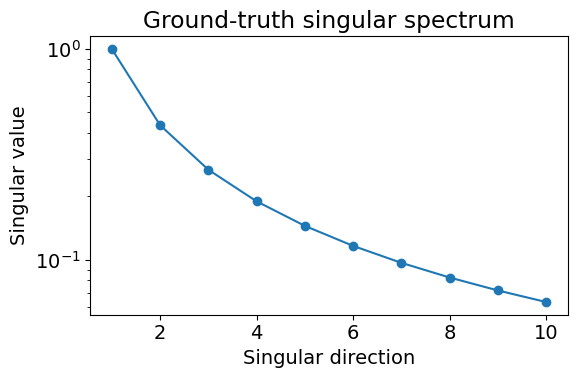

In [3]:
U, S, Vh = torch.linalg.svd(A, full_matrices=False)
print("Singular values of A:", S)

optimal_losses = []
optimal_params = []
for rank in range(1, latent_dim + 1):
    Ar = U[:, :rank] @ torch.diag(S[:rank]) @ Vh[:rank, :]
    loss = torch.mean((X_eval @ Ar - y_eval) ** 2).item()
    optimal_losses.append(loss)
    optimal_params.append((input_dim + output_dim) * rank)

plt.figure(figsize=(6, 4))
plt.plot(range(1, latent_dim + 1), S.cpu().numpy(), marker="o")
plt.yscale("log")
plt.xlabel("Singular direction")
plt.ylabel("Singular value")
plt.title("Ground-truth singular spectrum")
plt.tight_layout()
plt.show()


## Trainer API and samplers

Section 4 requires regression, so we locally adapt `StandardTrainer` and `FlexRankTrainer` to use `nn.MSELoss`. For NSL we can use the built-in `AllLayerLinearSampler`, and for single-profile training we can use `PredefinedModelsSampler`. The one exception is ASL: the current sampler API expresses rank profiles through `inner_dim`, which matches nested prefix truncation but cannot represent the arbitrary latent subsets required by Section 4.3.


In [4]:
@dataclass
class RegressionTrainerMixin:
    """Shared MSE training logic layered on top of the public trainer API."""

    def __post_init__(self, *args, **kwargs) -> None:
        super().__post_init__(*args, **kwargs)
        self.create_optimizer_and_scheduler(num_training_steps=num_updates)

    def _criterion(self) -> nn.Module:
        return nn.MSELoss()

    def train_epoch(self, epoch: int, criterion: nn.Module, max_steps: int | None = None) -> tuple[float, int]:
        assert self.optimizer is not None, "Optimizer must be created before training."
        assert self.lr_scheduler is not None, "Scheduler must be created before training."
        self.model.train()
        losses = []
        steps_taken = 0
        for batch_idx, (data, target) in enumerate(self._train_dataloader_iterator(), start=1):
            if max_steps is not None and steps_taken >= max_steps:
                break
            self.optimizer.zero_grad()
            _output, loss = self._forward_backward(data, target, criterion)
            self._clip_grad_norm()
            self.optimizer.step()
            self.lr_scheduler.step()
            losses.append(loss.item())
            steps_taken += 1
            if batch_idx % self.args.logging_steps == 0:
                print(f"epoch={epoch} batch={batch_idx} train_loss={np.mean(losses):.6f}")
        self._on_train_epoch_end()
        return (float(np.mean(losses)) if losses else 0.0), steps_taken

    @torch.no_grad()
    def evaluation_loop(
        self,
        dataloader=None,
        description=None,
        prediction_loss_only=None,
        ignore_keys=None,
        metric_key_prefix: str = "eval",
    ) -> EvalLoopOutput:
        _ = description, prediction_loss_only, ignore_keys
        eval_dataloader = dataloader if dataloader is not None else self.get_eval_dataloader()
        criterion = self._criterion()
        self.model.eval()
        total_loss = 0.0
        num_samples = len(eval_dataloader.dataset)
        for data, target in eval_dataloader:
            data = data.to(self.args.distr.device)
            target = target.to(self.args.distr.device)
            output = self.model(data)
            total_loss += criterion(output, target).item() * data.shape[0]
        metrics = {f"{metric_key_prefix}_loss": total_loss / num_samples}
        return EvalLoopOutput(
            predictions=None,
            label_ids=None,
            metrics=metrics,
            num_samples=num_samples,
        )

    def train(
        self,
        resume_from_checkpoint=None,
        trial=None,
        ignore_keys_for_eval=None,
    ) -> TrainOutput:
        unsupported_args = (resume_from_checkpoint, trial, ignore_keys_for_eval)
        assert all(arg is None for arg in unsupported_args), (
            "resume_from_checkpoint, trial, and ignore_keys_for_eval are not supported."
        )

        self.model.to(self.args.distr.device)
        criterion = self._criterion()
        epoch_losses = []
        eval_losses = []
        global_step = 0
        n_epochs = self.args.num_train_epochs
        for epoch in trange(1, n_epochs + 1, desc=self.__class__.__name__, leave=False):
            remaining_steps = num_updates - global_step
            if remaining_steps <= 0:
                break
            train_loss, steps_taken = self.train_epoch(epoch, criterion, max_steps=remaining_steps)
            global_step += steps_taken
            epoch_losses.append(train_loss)
            if self._do_validation(epoch):
                eval_metrics = self.evaluate(eval_dataset=self.eval_dataset, metric_key_prefix="eval")
                eval_losses.append(float(eval_metrics["eval_loss"]))
            if global_step >= num_updates:
                break
        training_loss = float(np.mean(epoch_losses)) if epoch_losses else 0.0
        metrics = {
            "train_loss": training_loss,
            "train_loss_history": epoch_losses,
        }
        if eval_losses:
            metrics["eval_loss"] = float(eval_losses[-1])
            metrics["eval_loss_history"] = eval_losses
        return TrainOutput(
            global_step=global_step,
            training_loss=training_loss,
            metrics=metrics,
        )


@dataclass
class RegressionStandardTrainer(RegressionTrainerMixin, StandardTrainer):
    pass


@dataclass
class RegressionFlexRankTrainer(RegressionTrainerMixin, FlexRankTrainer):
    pass


@dataclass
class AllSubspacesTrainer(RegressionStandardTrainer):
    """Notebook-local ASL trainer for arbitrary latent subsets.

    This is the only experiment not expressible with the built-in sampler API,
    because ASL requires arbitrary subsets rather than prefix ranks.
    """

    mask_bank: torch.Tensor | None = None

    def __post_init__(self) -> None:
        super().__post_init__()
        if self.mask_bank is None or self.mask_bank.ndim != 2:
            raise ValueError("mask_bank must have shape [num_masks, latent_dim].")
        if not hasattr(self.model, "linear") or not hasattr(self.model.linear, "in_network"):
            raise ValueError("AllSubspacesTrainer expects a decomposed `model.linear` layer.")
        if self.mask_bank.shape[1] != self.model.linear.max_inner_dim:
            raise ValueError("mask_bank width must match the decomposed latent dimension.")
        self.mask_bank = self.mask_bank.float().cpu()

    def _sample_mask(self, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
        idx = torch.randint(self.mask_bank.shape[0], (1,), device=device).item()
        return self.mask_bank[idx].to(device=device, dtype=dtype)

    def _forward_backward(self, data, target, criterion):
        layer = self.model.linear
        mask = self._sample_mask(data.device, layer.in_network.weight.dtype)
        hidden = layer.in_network(layer.dropout(data))
        output = layer.out_network(hidden * mask.unsqueeze(0)) * layer.scaling
        loss = criterion(output, target)
        loss.backward()
        return output, loss.detach()


def make_training_args(*, num_train_epochs=num_train_epochs):
    return TrainingArguments(
        output_dir="./outputs/linear_models",
        num_train_epochs=num_train_epochs,
        logging_steps=100_000,
        eval_strategy="epoch",
        per_device_train_batch_size=batch_size,
        eval_batch_size=n_eval,
        distr=distr,
    )


def make_flexrank_args(sampler_cls, sampler_kwargs, *, num_train_epochs=num_train_epochs):
    return FlexRankTrainArguments(
        output_dir="./outputs/linear_models",
        num_train_epochs=num_train_epochs,
        logging_steps=100_000,
        eval_strategy="epoch",
        per_device_train_batch_size=batch_size,
        eval_batch_size=n_eval,
        distr=distr,
        sampler_cls=sampler_cls,
        sampler_kwargs=sampler_kwargs,
    )


def make_standard_trainer(model, *, num_train_epochs=num_train_epochs):
    return RegressionStandardTrainer(
        model=model,
        args=make_training_args(num_train_epochs=num_train_epochs),
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        optimizer_cls=torch.optim.SGD,
        optimizer_kwargs={"lr": learning_rate, "momentum": momentum},
        scheduler_cls=torch.optim.lr_scheduler.ConstantLR,
        scheduler_kwargs={"factor": 1.0, "total_iters": 1},
    )


def make_flexrank_trainer(model, sampler_cls, sampler_kwargs, *, num_train_epochs=num_train_epochs):
    return RegressionFlexRankTrainer(
        model=model,
        args=make_flexrank_args(sampler_cls, sampler_kwargs, num_train_epochs=num_train_epochs),
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        optimizer_cls=torch.optim.SGD,
        optimizer_kwargs={"lr": learning_rate, "momentum": momentum},
        scheduler_cls=torch.optim.lr_scheduler.ConstantLR,
        scheduler_kwargs={"factor": 1.0, "total_iters": 1},
        do_distillation=False,
    )


def make_asl_trainer(model, mask_bank, *, num_train_epochs=num_train_epochs):
    return AllSubspacesTrainer(
        model=model,
        args=make_training_args(num_train_epochs=num_train_epochs),
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        optimizer_cls=torch.optim.SGD,
        optimizer_kwargs={"lr": learning_rate, "momentum": momentum},
        scheduler_cls=torch.optim.lr_scheduler.ConstantLR,
        scheduler_kwargs={"factor": 1.0, "total_iters": 1},
        mask_bank=mask_bank,
    )


def all_binary_masks(width: int) -> torch.Tensor:
    masks = []
    for mask in range(1, 2 ** width):
        bits = [(mask >> i) & 1 for i in range(width)]
        masks.append(bits)
    return torch.tensor(masks, dtype=torch.float32)


def nested_profiles(width: int) -> list[list[int]]:
    return [[rank] for rank in range(width, 0, -1)]


def pareto_front(params, losses):
    total_array = np.array([params, losses])
    sorted_indices = np.lexsort((total_array[1], total_array[0]))
    sorted_array = total_array[:, sorted_indices]
    pareto_params = []
    pareto_loss = []
    current_best_loss = float("inf")
    for p, l in zip(sorted_array[0], sorted_array[1]):
        if l < current_best_loss:
            pareto_params.append(float(p))
            pareto_loss.append(float(l))
            current_best_loss = l
    return np.array(pareto_params), np.array(pareto_loss)


@torch.no_grad()
def evaluate_all_subspaces(model, mask_bank):
    model = model.to(device).eval()
    layer = model.linear
    inputs = X_eval.to(device)
    targets = y_eval.to(device)
    criterion = nn.MSELoss()

    hidden = layer.in_network(layer.dropout(inputs))
    losses = []
    params = []
    ranks = []
    for mask in mask_bank.to(device=device, dtype=hidden.dtype):
        outputs = layer.out_network(hidden * mask.unsqueeze(0)) * layer.scaling
        losses.append(criterion(outputs, targets).item())
        rank = int(mask.sum().item())
        ranks.append(rank)
        params.append((input_dim + output_dim) * rank)
    return np.array(params), np.array(losses), np.array(ranks)


def best_submodel_gap(losses, ranks):
    gaps = []
    for rank in range(1, latent_dim + 1):
        best_rank_loss = float(np.min(losses[ranks == rank]))
        gaps.append(best_rank_loss - optimal_losses[rank - 1])
    return np.array(gaps)


def plot_experiment(params, losses, title, filename, *, show_legend=True):
    pareto_params, pareto_losses = pareto_front(params, losses)
    plt.figure(figsize=(6, 4))
    plt.scatter(params, losses, label="All 1023 submodels", alpha=0.25, s=20)
    plt.plot(pareto_params, pareto_losses, label="Best submodels", color="red", marker="o")
    plt.plot(
        optimal_params,
        optimal_losses,
        label="True Pareto front",
        color="green",
        marker="x",
    )
    plt.xlabel("Number of Parameters")
    plt.ylabel("Loss")
    plt.yscale("log")
    plt.title(title)
    if show_legend:
        plt.legend(loc=legend_position)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    return pareto_params, pareto_losses


## Factorized initialization

To match the original synthetic setup, we start from a randomly initialized dense linear map and convert it once into the decomposed `UV^⊤` parameterization. All three training strategies then start from the same factorized initialization.


In [5]:
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim, bias=False)

    def forward(self, x):
        return self.linear(x)


dense_seed_model = LinearModel().to(device)
svd_evaluator = make_standard_trainer(deepcopy(dense_seed_model).to(device), num_train_epochs=1)
svd_trainer = SVDTrainer(
    model=svd_evaluator.model,
    evaluator=svd_evaluator,
    args=SVDTrainingArguments(
        svd_type=SVDType.SVD,
        distr=distr,
    ),
)
svd_output = svd_trainer.train()
reference_decomposed_model = deepcopy(svd_evaluator.model).to(device)
rank_width = reference_decomposed_model.linear.max_inner_dim
all_mask_bank = all_binary_masks(rank_width)
pts_profiles = [[rank_width]]
nsl_profiles = nested_profiles(rank_width)

print("Decomposed layers:", svd_output.decomposed_layers)
print(f"Latent rank width: {rank_width}")
print(f"Total subspaces in Figure 2: {len(all_mask_bank)}")


svd (worker 0): decomposing layer linear: 100%|██████████| 1/1 [00:00<00:00, 16.72it/s]
                                     

Decomposed layers: ['linear']
Latent rank width: 10
Total subspaces in Figure 2: 1023


## 4.2 Post-Training Selection (PTS)

Main insight from the paper: optimizing only the full model and selecting submodels afterward does not recover the Pareto-optimal rank-reduced solutions. Theorem 4.1 shows that, under generic conditions, the probability that full-model training alone yields the right lower-rank subspaces is zero; Figure 2(a) visualizes the resulting positive submodel gap.


RegressionFlexRankTrainer:   0%|          | 0/11 [00:00<?, ?it/s]

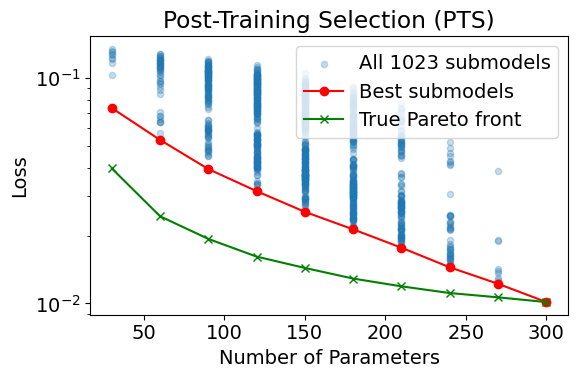

Final full-model eval loss: 0.010151
Max best-submodel gap: 0.033733


In [6]:
pts_model = deepcopy(reference_decomposed_model).to(device)
pts_trainer = make_flexrank_trainer(
    pts_model,
    PredefinedModelsSampler,
    {"samples": pts_profiles},
)
pts_output = pts_trainer.train()
pts_eval = pts_trainer.evaluate()
pts_params, pts_losses, pts_ranks = evaluate_all_subspaces(pts_trainer.model, all_mask_bank)
pts_gap = best_submodel_gap(pts_losses, pts_ranks)
pts_pareto = plot_experiment(
    pts_params,
    pts_losses,
    "Post-Training Selection (PTS)",
    "linear_model_pareto_full_only.png",
)
print(f"Final full-model eval loss: {pts_eval['eval_loss']:.6f}")
print(f"Max best-submodel gap: {pts_gap.max():.6f}")


## 4.3 All-Subspaces Learning (ASL)

Main insight from the paper: once PTS fails, training all possible submodels looks natural, but it still degrades the Pareto front. Theorem 4.2 attributes this to interference between submodels of the same rank, which compete for representational capacity and keep the best-submodel gap strictly positive.


AllSubspacesTrainer:   0%|          | 0/11 [00:00<?, ?it/s]

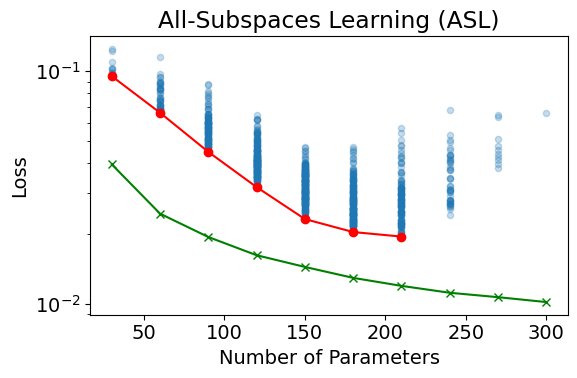

Final ASL eval loss: 0.065608
Max best-submodel gap: 0.055462


In [7]:
asl_model = deepcopy(reference_decomposed_model).to(device)
asl_trainer = make_asl_trainer(asl_model, all_mask_bank)
asl_output = asl_trainer.train()
asl_eval = asl_trainer.evaluate()
asl_params, asl_losses, asl_ranks = evaluate_all_subspaces(asl_trainer.model, all_mask_bank)
asl_gap = best_submodel_gap(asl_losses, asl_ranks)
asl_pareto = plot_experiment(
    asl_params,
    asl_losses,
    "All-Subspaces Learning (ASL)",
    "linear_model_pareto_all.png",
    show_legend=False,
)
print(f"Final ASL eval loss: {asl_eval['eval_loss']:.6f}")
print(f"Max best-submodel gap: {asl_gap.max():.6f}")


## 4.4 Nested Subspace Learning (NSL)

Main insight from the paper: nested training resolves the interference problem by optimizing exactly one prefix submodel per rank. Theorem 4.3 shows that each additional component only needs to fit the residual `A_{r+1} - A_r`, so the best-submodel gap collapses to zero in theory and Figure 2(c) reaches the true Pareto front.


RegressionFlexRankTrainer:   0%|          | 0/11 [00:00<?, ?it/s]

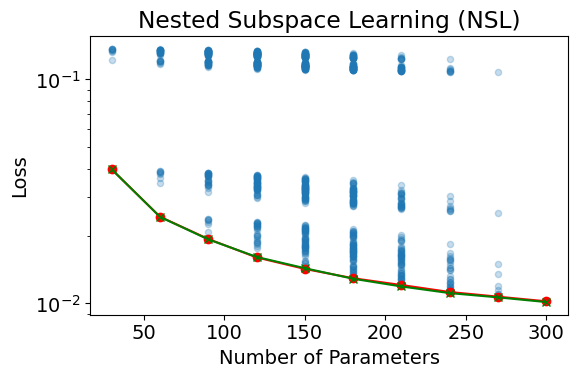

Final NSL eval loss: 0.010227
Max best-submodel gap: 0.000177


In [8]:
nsl_model = deepcopy(reference_decomposed_model).to(device)
nsl_trainer = make_flexrank_trainer(
    nsl_model,
    AllLayerLinearSampler,
    {"min_p": 0.1, "num_models": rank_width},
)
nsl_output = nsl_trainer.train()
nsl_eval = nsl_trainer.evaluate()
nsl_params, nsl_losses, nsl_ranks = evaluate_all_subspaces(nsl_trainer.model, all_mask_bank)
nsl_gap = best_submodel_gap(nsl_losses, nsl_ranks)
nsl_pareto = plot_experiment(
    nsl_params,
    nsl_losses,
    "Nested Subspace Learning (NSL)",
    "linear_model_pareto_nested.png",
    show_legend=False,
)
print(f"Final NSL eval loss: {nsl_eval['eval_loss']:.6f}")
print(f"Max best-submodel gap: {nsl_gap.max():.6f}")


## Comparison summary

Figure 2 is the central message of Section 4: PTS fails because full-model training does not identify the right lower-rank directions; ASL also fails because arbitrary same-rank submodels interfere with each other; NSL succeeds because nested prefix objectives are compatible and therefore recover the Pareto elastic solution.


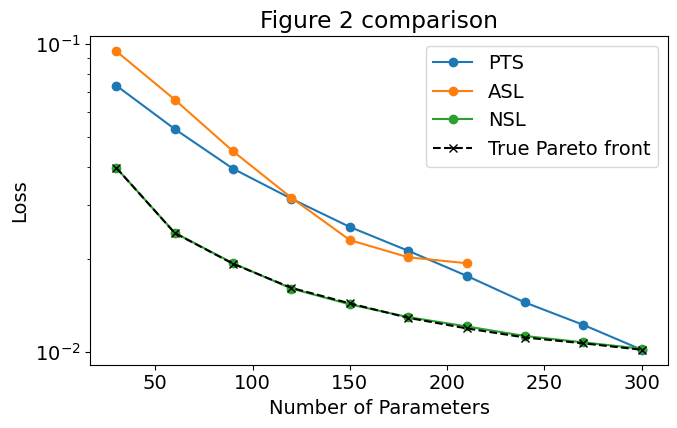

{'PTS_max_best_submodel_gap': 0.03373253718018532,
 'ASL_max_best_submodel_gap': 0.05546156968921423,
 'NSL_max_best_submodel_gap': 0.0001769689843058586,
 'PTS_final_eval_loss': 0.01015083584934473,
 'ASL_final_eval_loss': 0.06560821831226349,
 'NSL_final_eval_loss': 0.010227149352431297}

In [9]:
plt.figure(figsize=(7, 4.5))
plt.plot(pts_pareto[0], pts_pareto[1], marker="o", label="PTS")
plt.plot(asl_pareto[0], asl_pareto[1], marker="o", label="ASL")
plt.plot(nsl_pareto[0], nsl_pareto[1], marker="o", label="NSL")
plt.plot(optimal_params, optimal_losses, marker="x", linestyle="--", color="black", label="True Pareto front")
plt.xlabel("Number of Parameters")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Figure 2 comparison")
plt.legend(loc=legend_position)
plt.tight_layout()
plt.savefig("linear_model_pareto_comparison.png", dpi=200)
plt.show()

summary = {
    "PTS_max_best_submodel_gap": float(pts_gap.max()),
    "ASL_max_best_submodel_gap": float(asl_gap.max()),
    "NSL_max_best_submodel_gap": float(nsl_gap.max()),
    "PTS_final_eval_loss": float(pts_eval["eval_loss"]),
    "ASL_final_eval_loss": float(asl_eval["eval_loss"]),
    "NSL_final_eval_loss": float(nsl_eval["eval_loss"]),
}
summary
